### VLM VQA 데이터셋 파인튜닝 예시

In [16]:
import torch, os
from datasets import load_dataset
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, BitsAndBytesConfig, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from qwen_vl_utils import process_vision_info

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "Qwen/Qwen2-VL-2B-Instruct"


학습 데이터셋 준비

In [3]:

print("데이터셋 로드 중...")
dataset = load_dataset("merve/vqav2-small", split="validation[:1000]")  
train_test = dataset.train_test_split(test_size=0.15, shuffle=True, seed=42) 
train_dataset = train_test["train"]
eval_dataset = train_test["test"]
print(f"학습 데이터 수: {len(train_dataset)}, 평가 데이터 수: {len(eval_dataset)}")


데이터셋 로드 중...
학습 데이터 수: 850, 평가 데이터 수: 150


VLM 모델 로딩

In [4]:
# 4비트 양자화 모델 및 프로세서 로드
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

model = prepare_model_for_kbit_training(model) # 양자화 모델 준비

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\envs\venv_mm\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\ProgramData\anaconda3\envs\venv_mm\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\ProgramData\anaconda3\envs\venv_mm\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 6: invalid start byte


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

추론(Inference) 함수 정의

In [5]:
def generate_answer(image, question):
    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": f"Question: {question} Answer briefly."}
        ]}
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    img_info, _ = process_vision_info(messages)
    
    inputs = processor(text=[text], images=img_info, return_tensors="pt", padding=True).to(device)
    
    model.eval()
    with torch.no_grad():
        gen_ids = model.generate(**inputs, max_new_tokens=20, do_sample=False)
        trimmed_ids = [out[len(inp):] for inp, out in zip(inputs.input_ids, gen_ids)]
        return processor.batch_decode(trimmed_ids, skip_special_tokens=True)[0]


테스트용 기준 데이터

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



[파인튜닝 전 샘플 검증]
질문 7: Are these professional cooks? | 정답: yes | 예측: yes
질문 8: How many oranges are on pedestals? | 정답: 5 | 예측: 3
질문 9: Where is the sign? | 정답: behind fence | 예측: parking lot


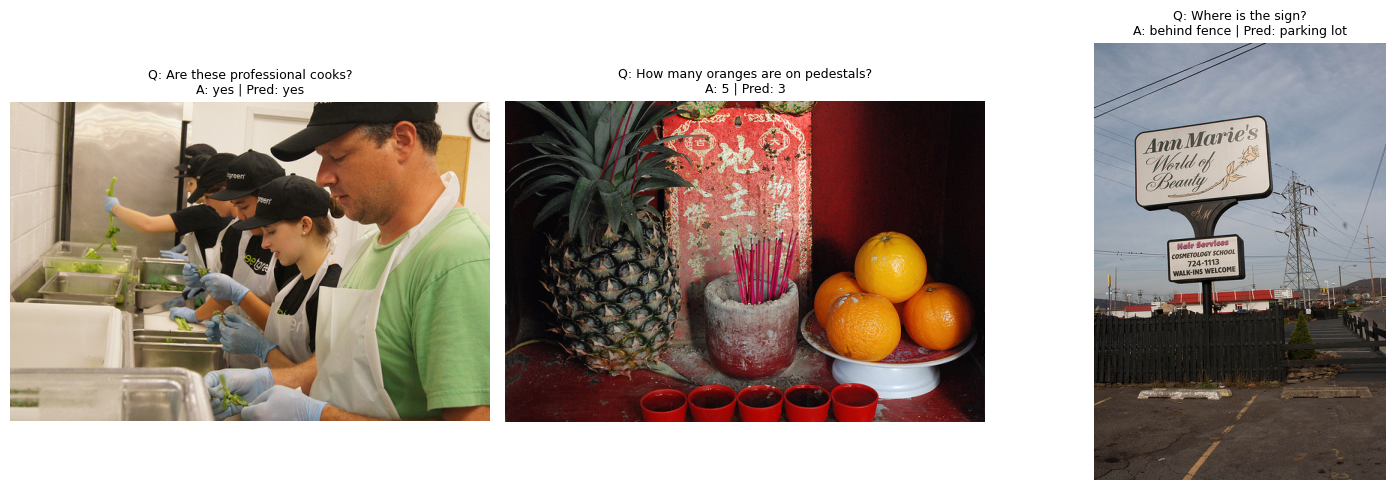

In [6]:
import matplotlib.pyplot as plt

print("\n[파인튜닝 전 샘플 검증]")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, i in enumerate([6, 7, 8]):
    test_sample = train_dataset[i]
    test_img = test_sample["image"].convert("RGB")
    test_q = test_sample["question"]
    test_pred = generate_answer(test_img, test_q)
    print(f"질문 {i+1}: {test_q} | 정답: {test_sample['multiple_choice_answer']} | 예측: {test_pred}")
    
    axes[idx].imshow(test_img)
    axes[idx].axis('off')
    axes[idx].set_title(f"Q: {test_q}\nA: {test_sample['multiple_choice_answer']} | Pred: {test_pred}", fontsize=9)
plt.tight_layout()
plt.show()

LoRA 파인튜닝 파라메터 설정

In [7]:
# LoRA 설정
lora_config = LoraConfig(
    r=32,                 
    lora_alpha=64,        
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",  # Attention
        "gate_proj", "up_proj", "down_proj"      # FFN 추가
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.enable_input_require_grads()
# model.gradient_checkpointing_enable()  # 주석 처리하고 메모리 문제 시에만 활성화

print(f"학습 가능한 파라미터: {model.get_nb_trainable_parameters()}")

학습 가능한 파라미터: (36929536, 2245915136)


전처리 및 마스킹(Loss 제외 처리)용 콜레이터 함수 정의

In [8]:
def vqa_collator(examples):
    texts, images = [], []
    for ex in examples:
        msgs = [
            {"role": "user", "content": [
                {"type": "image", "image": ex["image"].convert("RGB")},
                {"type": "text", "text": f"Question: {ex['question']} Answer briefly."}
            ]},
            {"role": "assistant", "content": [{"type": "text", "text": ex["multiple_choice_answer"]}]}
        ]
        texts.append(processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False))
        img_info, _ = process_vision_info(msgs)
        if img_info: images.extend(img_info)
        
    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()
    
    # 모델의 답변 부분만 학습하도록 assistant 토큰 이전은 -100으로 마스킹
    assistant_token_id = processor.tokenizer.encode("<|im_start|>assistant", add_special_tokens=False)[0]
    
    for i in range(labels.shape[0]):
        token_list = labels[i].tolist()
        try:
            start_idx = token_list.index(assistant_token_id) + 2
            labels[i, :start_idx] = -100
        except ValueError:
            labels[i, :len(token_list) // 2] = -100
            
    batch["labels"] = labels
    return batch


학습 파라메터, 객체 정의 및 파인튜닝 학습 

In [10]:
# 학습 하이퍼파라미터
trainer = Trainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=vqa_collator,
    args=TrainingArguments(
        output_dir="./vqa_model",
        per_device_train_batch_size=2,          
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=1e-4,                     
        num_train_epochs=5,                     
        warmup_ratio=0.1,                 # warmup_steps 대신 ratio 사용
        weight_decay=0.01,
        optim="paged_adamw_8bit",
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=50,                    
        save_strategy="steps",
        save_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        save_total_limit=3,
        remove_unused_columns=False,
        bf16=True,
        gradient_checkpointing=False,     # 명시적으로 비활성화
        report_to="none",
        # early_stopping_patience=3,  # eval_loss 개선이 없으면 조기 종료
    )
)

print("모델 파인튜닝 시작")
model.train()
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


모델 파인튜닝 시작


C:\Users\laput\AppData\Roaming\Python\Python311\site-packages\torch\_dynamo\eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
50,7.375750,7.278397
100,7.203619,7.194081
150,7.201797,7.191045
200,7.192252,7.189744
250,7.191943,7.189676
300,7.195986,7.190259
350,7.179776,7.190517
400,7.183725,7.190239
450,7.206967,7.191793
500,7.175982,7.190703


C:\Users\laput\AppData\Roaming\Python\Python311\site-packages\torch\_dynamo\eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
C:\Users\laput\AppData\Roaming\Python\Python311\site-packages\torch\_dynamo\eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
C:\Users\l

TrainOutput(global_step=535, training_loss=7.601314715804341, metrics={'train_runtime': 2728.8815, 'train_samples_per_second': 1.557, 'train_steps_per_second': 0.196, 'total_flos': 2.169736221778944e+16, 'train_loss': 7.601314715804341, 'epoch': 5.0})

학습 후 추론 (After) 확인

In [11]:
print("\n[학습 후 샘플 검증]")
for i in [6, 7, 8]:
    test_sample = train_dataset[i]
    test_img = test_sample["image"].convert("RGB")
    test_q = test_sample["question"]
    test_pred = generate_answer(test_img, test_q)
    print(f"질문 {i+1}: {test_q} | 정답: {test_sample['multiple_choice_answer']} | 예측: {test_pred}")

# 모델 저장
print("\n모델 저장 중...")
model.save_pretrained("vqa_model/final_model")
processor.save_pretrained("vqa_model/final_model")
print("완료!")



[학습 후 샘플 검증]
질문 7: Are these professional cooks? | 정답: yes | 예측: yes
질문 8: How many oranges are on pedestals? | 정답: 5 | 예측: 4
질문 9: Where is the sign? | 정답: behind fence | 예측: on pole

모델 저장 중...
완료!


파인튜닝된 모델 로딩

In [ ]:
base_model_id = "Qwen/Qwen2-VL-2B-Instruct" # 원본 거대 모델
lora_model_path = "./vqa_model/final_model"

print("프로세서 로드 중...")
processor = AutoProcessor.from_pretrained(lora_model_path)

print("원본 베이스 모델 로드 중...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

print("학습된 LoRA 가중치 결합 중...")
model = PeftModel.from_pretrained(base_model, lora_model_path)
print("모델 로딩 완료. 추론(Inference)이 가능합니다.")

print("\n[학습 후 샘플 검증]")
for i in [6, 7, 8]:
    test_sample = train_dataset[i]
    test_img = test_sample["image"].convert("RGB")
    test_q = test_sample["question"]
    test_pred = generate_answer(test_img, test_q)
    print(f"질문 {i+1}: {test_q} | 정답: {test_sample['multiple_choice_answer']} | 예측: {test_pred}")


프로세서 로드 중...
원본 베이스 모델 로드 중...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

학습된 LoRA 가중치 결합 중...
모델 로딩 완료. 추론(Inference)이 가능합니다.
